# Analisis Downsampling — Simulasi Interaksi dengan 4 Metode Augmentasi

Notebook ini menghasilkan simulasi dan visualisasi untuk mendukung penulisan **Subbab IV.8.4**.

**Tiga konfigurasi yang dibandingkan:**
- **Config A** — Tanpa Downsampling: `Augmentasi(T) → model menerima T_aug`
- **Config B** — DS Sebelum Aug: `DS(T) → T/2 → Augmentasi(T/2) → model menerima T_aug_short`  
- **Config C** — DS Sesudah Aug: `Augmentasi(T) → T_aug → DS(T_aug) → model menerima T_aug/2`

| Cell | Konten |
|------|--------|
| 2 | Setup, kelas augmentasi, data |
| 3 | **Sim-1**: Simulasi perbedaan $T_{in}$ ke augmentasi per konfigurasi |
| 4 | **Sim-2**: Interaksi DS × TemporalRescale (efek pada `new_len`) |
| 5 | **Sim-3**: Interaksi DS × TemporalDrop (efek pada proporsi dan posisi dropout) |
| 6 | **Sim-4**: Interaksi DS × Spatial Jitter dan Spatial Scale |
| 7 | **Viz-1**: Ringkasan distribusi $T_{out}$ ke model untuk semua konfigurasi × augmentasi |
| 8 | **Viz-2**: Timeline visualisasi 3 konfigurasi pada 1 video (5 epoch) |

## Cell 2 — Setup, Kelas, Data

In [16]:
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import os
from collections import defaultdict

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

PICKLE_FILE  = '../data/pickle/pose_bisindo.pkl'
OUTPUT_DIR   = 'docs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SELECTED_ID  = 'P1_S15_R1'
TEMP_SCALING = 0.2
N_EPOCHS     = 5
N_SIM        = 40   # simulasi Monte Carlo
DS_RATIO     = 0.5
ALLOWED_REPS = {'R1', 'R2', 'R3', 'R4'}

COLOR_A = '#2166AC'   # Config A — tanpa DS
COLOR_B = '#D6604D'   # Config B — DS sebelum aug
COLOR_C = '#4DAC26'   # Config C — DS sesudah aug
LABEL_A = 'Config A: Tanpa DS'
LABEL_B = 'Config B: DS Sebelum Aug'
LABEL_C = 'Config C: DS Sesudah Aug'

# ── Kelas augmentasi (identik dengan pipeline) ────────────────────────────────

SENTENCE_LENGTH_BOUNDS = {
    "S01": {"min_len": 115, "max_len": 245}, "S02": {"min_len": 179, "max_len": 255},
    "S03": {"min_len": 105, "max_len": 180}, "S04": {"min_len": 184, "max_len": 315},
    "S05": {"min_len": 172, "max_len": 485}, "S06": {"min_len": 110, "max_len": 235},
    "S07": {"min_len": 220, "max_len": 390}, "S08": {"min_len": 159, "max_len": 380},
    "S09": {"min_len": 194, "max_len": 310}, "S10": {"min_len":  95, "max_len": 185},
    "S11": {"min_len": 123, "max_len": 215}, "S12": {"min_len": 200, "max_len": 335},
    "S13": {"min_len": 150, "max_len": 290}, "S14": {"min_len": 135, "max_len": 330},
    "S15": {"min_len":  95, "max_len": 210}, "S16": {"min_len": 154, "max_len": 320},
    "S17": {"min_len": 185, "max_len": 330}, "S18": {"min_len": 127, "max_len": 240},
    "S19": {"min_len": 155, "max_len": 380}, "S20": {"min_len":  96, "max_len": 220},
    "S21": {"min_len": 164, "max_len": 283}, "S22": {"min_len": 179, "max_len": 375},
    "S23": {"min_len": 110, "max_len": 265}, "S24": {"min_len":  81, "max_len": 165},
    "S25": {"min_len": 203, "max_len": 465}, "S26": {"min_len": 183, "max_len": 310},
    "S27": {"min_len":  95, "max_len": 240}, "S28": {"min_len":  91, "max_len": 210},
    "S29": {"min_len": 145, "max_len": 230}, "S30": {"min_len": 141, "max_len": 260},
}

class Downsample:
    def __init__(self, ratio=0.5, random_offset=True):
        self.step = max(1, int(round(1.0 / ratio)))
        self.random_offset = random_offset
    def __call__(self, clip, **kwargs):
        start = 0 if (not self.random_offset or random.uniform(0,1) > 0.5) else 1
        return clip[list(range(start, len(clip), self.step))]

class Jitter:
    def __init__(self, std_dev=0.006): self.std_dev = std_dev
    def __call__(self, skeleton, **kwargs):
        return skeleton + np.random.normal(0, self.std_dev, skeleton.shape)

class Scale:
    def __init__(self, scale_range=(0.8, 1.2)): self.scale_range = scale_range
    def __call__(self, skeleton, **kwargs):
        T = skeleton.shape[0]
        scales = np.random.uniform(*self.scale_range, size=T)
        return skeleton * scales[:, np.newaxis, np.newaxis]

class TemporalDropout:
    def __init__(self, max_dp=0.2): self.max_dp = max_dp
    def __call__(self, skeleton, **kwargs):
        vid_len = len(skeleton)
        dp_len  = int(vid_len * self.max_dp * np.random.random())
        start   = np.random.randint(0, vid_len - dp_len + 1)
        end     = start + dp_len
        index   = list(range(0, start)) + list(range(end, vid_len))
        return skeleton[index]

class TemporalRescale:
    def __init__(self, temp_scaling=0.2, bounds=None, default_min_len=32, default_max_len=230):
        self.bounds          = bounds if bounds is not None else SENTENCE_LENGTH_BOUNDS
        self.default_min_len = default_min_len
        self.default_max_len = default_max_len
        self.L = 1.0 - temp_scaling
        self.U = 1.0 + temp_scaling
    def __call__(self, clip, sentence_id=None, **kwargs):
        b       = self.bounds.get(sentence_id, {})
        min_len = b.get('min_len', self.default_min_len)
        max_len = b.get('max_len', self.default_max_len)
        vid_len = len(clip)
        new_len = int(vid_len * np.random.uniform(self.L, self.U))
        new_len = max(min_len, min(new_len, max_len))
        if (new_len - 4) % 4 != 0:
            new_len += 4 - (new_len - 4) % 4
        new_len = max(min_len, min(new_len, max_len))
        if new_len <= vid_len:
            index = sorted(random.sample(range(vid_len), new_len))
        else:
            index = sorted(random.choices(range(vid_len), k=new_len))
        return clip[index]

# ── Instance augmentasi ───────────────────────────────────────────────────────
ds        = Downsample(ratio=DS_RATIO, random_offset=True)
jitter    = Jitter(std_dev=0.006)
scale     = Scale(scale_range=(0.8, 1.2))
td        = TemporalDropout(max_dp=0.2)
tr        = TemporalRescale(temp_scaling=TEMP_SCALING)

AUG_FUNCS = {'Jitter': jitter, 'Scale': scale, 'TemporalDrop': td, 'TemporalRescale': tr}

# ── Load data ─────────────────────────────────────────────────────────────────
with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

assert SELECTED_ID in data
skeleton    = data[SELECTED_ID]['keypoints'].copy()   # (T, 86, 2)
sentence_id = SELECTED_ID.split('_')[1]
T           = len(skeleton)
T_ds        = len(ds(skeleton.copy()))                # T setelah DS ≈ T//2

print(f'Video       : {SELECTED_ID}  |  sentence_id = {sentence_id}')
print(f'T (asli)    : {T} frame')
print(f'T (setelah DS ratio={DS_RATIO}): {T_ds} frame')
print(f'S15 bounds  : {SENTENCE_LENGTH_BOUNDS[sentence_id]}')

Video       : P1_S15_R1  |  sentence_id = S15
T (asli)    : 115 frame
T (setelah DS ratio=0.5): 58 frame
S15 bounds  : {'min_len': 95, 'max_len': 210}


## Cell 3 — Sim-1: Perbedaan $T_{in}$ ke Augmentasi per Konfigurasi

Menunjukkan bahwa titik masuk augmentasi sudah berbeda antara Config A, B, C — **sebelum augmentasi itu sendiri berjalan**.

In [17]:
np.random.seed(0); random.seed(0)

# Simulasi T_ds untuk N_SIM epoch (random_offset membuat T_ds bervariasi)
T_ds_samples = [len(ds(skeleton.copy())) for _ in range(N_SIM)]
T_ds_vals    = np.array(T_ds_samples)

print('SIM-1: T Input ke Augmentasi per Konfigurasi')
print('=' * 80)
print(f"{'Konfigurasi':<35} {'T_in ke aug':<20} {'Keterangan'}")
print('-' * 80)
print(f"{'Config A (Tanpa DS)':<35} {'T = ' + str(T):<20} Augmentasi bekerja pada sekuens penuh")
print(f"{'Config B (DS Sebelum Aug)':<35} {'T/2 ≈ ' + str(T_ds):<20} Augmentasi bekerja pada sekuens dipersempit")
print(f"{'Config C (DS Sesudah Aug)':<35} {'T = ' + str(T):<20} Augmentasi bekerja pada sekuens penuh")
print('=' * 80)
print()
print(f'Catatan random_offset pada Downsample:')
print(f'  start=0: frame [0, 2, 4, ...] → T_ds = {len(range(0, T, 2))}')
print(f'  start=1: frame [1, 3, 5, ...] → T_ds = {len(range(1, T, 2))}')
print(f'  Dari {N_SIM} simulasi: mean={T_ds_vals.mean():.1f}, min={T_ds_vals.min()}, max={T_ds_vals.max()}')
print()
print('Implikasi:')
print(f'  Augmentasi Temporal (TD, TR) pada Config B bekerja pada T_in ≈ {T_ds} (bukan {T})')
print(f'  → dp_len = int({T_ds} × 0.2 × r)  maks = {int(T_ds*0.2)} frame  (vs {int(T*0.2)} frame pada Config A/C)')
print(f'  → new_len_TR = int({T_ds} × f)     range [{int(T_ds*0.8)}, {int(T_ds*1.2)}]  (vs [{int(T*0.8)}, {int(T*1.2)}] pada Config A/C)')

SIM-1: T Input ke Augmentasi per Konfigurasi
Konfigurasi                         T_in ke aug          Keterangan
--------------------------------------------------------------------------------
Config A (Tanpa DS)                 T = 115              Augmentasi bekerja pada sekuens penuh
Config B (DS Sebelum Aug)           T/2 ≈ 58             Augmentasi bekerja pada sekuens dipersempit
Config C (DS Sesudah Aug)           T = 115              Augmentasi bekerja pada sekuens penuh

Catatan random_offset pada Downsample:
  start=0: frame [0, 2, 4, ...] → T_ds = 58
  start=1: frame [1, 3, 5, ...] → T_ds = 57
  Dari 40 simulasi: mean=57.6, min=57, max=58

Implikasi:
  Augmentasi Temporal (TD, TR) pada Config B bekerja pada T_in ≈ 58 (bukan 115)
  → dp_len = int(58 × 0.2 × r)  maks = 11 frame  (vs 23 frame pada Config A/C)
  → new_len_TR = int(58 × f)     range [46, 69]  (vs [92, 138] pada Config A/C)


## Cell 4 — Sim-2: Interaksi DS × TemporalRescale

TemporalRescale menggunakan `new_len = int(T_in × f)` — sehingga perbedaan `T_in` antara Config A/C vs Config B langsung memengaruhi distribusi `T_out` **meskipun `f` dan bounds sama**.

SIM-2a: Efek f yang Sama pada T_in Berbeda (TemporalRescale)
bounds S15 = [95, 210]  |  T = 115  |  T_ds = 58
f       T_in (A/C)    new_len raw     T_out (A/C)     T_in (B)      new_len raw     T_out (B)       T_out A/C vs B
----------------------------------------------------------------------------------------------------
0.82    115           94              96              58            47              96              A/C=96 vs B=96  (Δ=+0)
0.92    115           105             108             58            53              96              A/C=108 vs B=96  (Δ=+12)
1.00    115           115             116             58            58              96              A/C=116 vs B=96  (Δ=+20)
1.10    115           126             128             58            63              96              A/C=128 vs B=96  (Δ=+32)
1.18    115           135             136             58            68              96              A/C=136 vs B=96  (Δ=+40)

Catatan Config C: T_out_aug kemudian di-DS lagi → 

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\3751580075.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


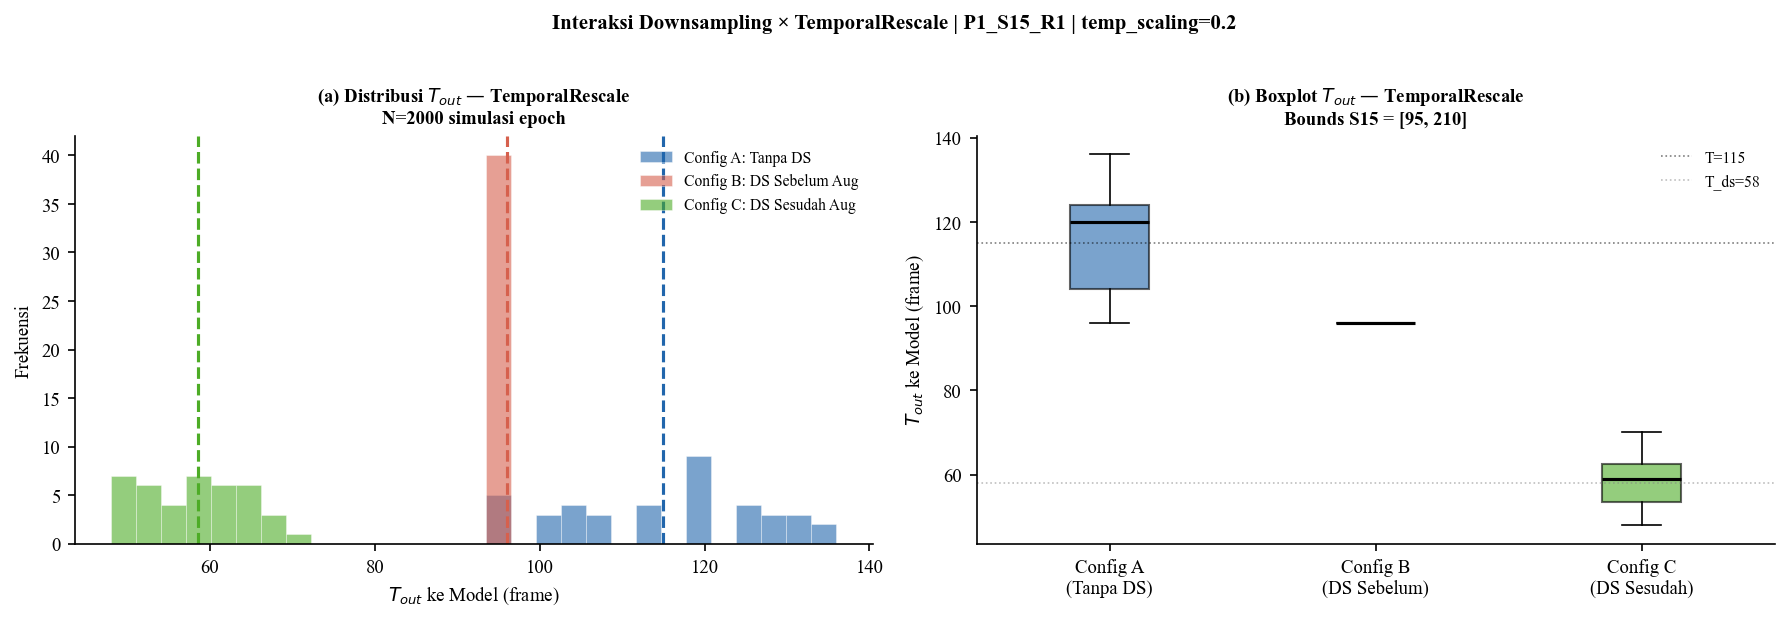

[SAVED] ds_x_temporal_rescale.png


In [18]:
np.random.seed(42); random.seed(42)

b_s15   = SENTENCE_LENGTH_BOUNDS[sentence_id]
mn, mx  = b_s15['min_len'], b_s15['max_len']

# ── Tabel deterministik: 5 nilai f yang sama diterapkan ke T dan T/2 ──────────
f_vals = [0.82, 0.92, 1.00, 1.10, 1.18]

def apply_tr_logic(T_in, f, mn, mx):
    new_len = int(T_in * f)
    new_len = max(mn, min(new_len, mx))
    if (new_len - 4) % 4 != 0:
        new_len += 4 - (new_len - 4) % 4
    new_len = max(mn, min(new_len, mx))
    return new_len

print('SIM-2a: Efek f yang Sama pada T_in Berbeda (TemporalRescale)')
print(f'bounds S15 = [{mn}, {mx}]  |  T = {T}  |  T_ds = {T_ds}')
print('=' * 100)
header = (
    f"{'f':<8}"
    f"{'T_in (A/C)':<14}"
    f"{'new_len raw':<16}"
    f"{'T_out (A/C)':<16}"
    f"{'T_in (B)':<14}"
    f"{'new_len raw':<16}"
    f"{'T_out (B)':<16}"
    f"{'T_out A/C vs B'}"
)
print(header)
print('-' * 100)
for f in f_vals:
    tout_ac = apply_tr_logic(T, f, mn, mx)
    tout_b  = apply_tr_logic(T_ds, f, mn, mx)
    # Config C: T_out kemudian di-DS lagi
    tout_c_after_ds = max(1, tout_ac // 2)
    raw_ac = int(T * f)
    raw_b  = int(T_ds * f)
    diff   = tout_ac - tout_b
    print(
        f"{f:<8.2f}"
        f"{T:<14}"
        f"{raw_ac:<16}"
        f"{tout_ac:<16}"
        f"{T_ds:<14}"
        f"{raw_b:<16}"
        f"{tout_b:<16}"
        f"A/C={tout_ac} vs B={tout_b}  (Δ={diff:+d})"
    )
print('=' * 100)
print()
print('Catatan Config C: T_out_aug kemudian di-DS lagi → model menerima ≈ T_out/2')
print()

# ── Monte Carlo: distribusi T_out untuk N_SIM epoch ───────────────────────────
np.random.seed(0); random.seed(0)

tout_A, tout_B, tout_C = [], [], []
for _ in range(N_SIM):
    skel_copy = skeleton.copy()

    # Config A: TR(T) → T_out_A
    out_a = tr(skel_copy.copy(), sentence_id=sentence_id)
    tout_A.append(len(out_a))

    # Config B: DS(T) → TR(T_ds) → T_out_B
    out_b = tr(ds(skel_copy.copy()), sentence_id=sentence_id)
    tout_B.append(len(out_b))

    # Config C: TR(T) → DS(T_out_A) → T_out_C
    out_c = ds(tr(skel_copy.copy(), sentence_id=sentence_id))
    tout_C.append(len(out_c))

tout_A = np.array(tout_A)
tout_B = np.array(tout_B)
tout_C = np.array(tout_C)

print('SIM-2b: Distribusi T_out ke Model (N=2000 simulasi epoch)')
print(f'{"Konfigurasi":<35} {"Min":>6} {"Mean":>8} {"Max":>6} {"Std":>8} {"Range":>8}')
print('-' * 75)
for label, arr in [(LABEL_A, tout_A), (LABEL_B, tout_B), (LABEL_C, tout_C)]:
    print(f'{label:<35} {arr.min():>6} {arr.mean():>8.1f} {arr.max():>6} {arr.std():>8.1f} {arr.max()-arr.min():>8}')

# ── Visualisasi distribusi T_out ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bins = np.linspace(min(tout_A.min(), tout_B.min(), tout_C.min()),
                   max(tout_A.max(), tout_B.max(), tout_C.max()), 30)
ax.hist(tout_A, bins=bins, color=COLOR_A, alpha=0.6, label=LABEL_A, edgecolor='white', lw=0.3)
ax.hist(tout_B, bins=bins, color=COLOR_B, alpha=0.6, label=LABEL_B, edgecolor='white', lw=0.3)
ax.hist(tout_C, bins=bins, color=COLOR_C, alpha=0.6, label=LABEL_C, edgecolor='white', lw=0.3)
for arr, c in [(tout_A, COLOR_A), (tout_B, COLOR_B), (tout_C, COLOR_C)]:
    ax.axvline(arr.mean(), color=c, lw=1.5, ls='--')
ax.set_xlabel('$T_{out}$ ke Model (frame)', fontsize=9)
ax.set_ylabel('Frekuensi', fontsize=9)
ax.set_title('(a) Distribusi $T_{out}$ — TemporalRescale\nN=2000 simulasi epoch', fontsize=9)
ax.legend(fontsize=7.5, frameon=False)
for s in ['top','right']: ax.spines[s].set_visible(False)

# Boxplot perbandingan
ax2 = axes[1]
bp = ax2.boxplot(
    [tout_A, tout_B, tout_C],
    labels=['Config A\n(Tanpa DS)', 'Config B\n(DS Sebelum)', 'Config C\n(DS Sesudah)'],
    patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgecolor='none')
)
for patch, c in zip(bp['boxes'], [COLOR_A, COLOR_B, COLOR_C]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax2.set_ylabel('$T_{out}$ ke Model (frame)', fontsize=9)
ax2.set_title(
    f'(b) Boxplot $T_{{out}}$ — TemporalRescale\nBounds S15 = [{mn}, {mx}]',
    fontsize=9
)
ax2.axhline(T,    color='black', lw=0.8, ls=':', alpha=0.5, label=f'T={T}')
ax2.axhline(T_ds, color='gray',  lw=0.8, ls=':', alpha=0.5, label=f'T_ds={T_ds}')
ax2.legend(fontsize=7.5, frameon=False)
for s in ['top','right']: ax2.spines[s].set_visible(False)

fig.suptitle(
    f'Interaksi Downsampling × TemporalRescale | {SELECTED_ID} | temp_scaling={TEMP_SCALING}',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ds_x_temporal_rescale.png'), dpi=600, bbox_inches='tight')
plt.show()
print('[SAVED] ds_x_temporal_rescale.png')

## Cell 5 — Sim-3: Interaksi DS × TemporalDrop

TemporalDrop menghapus segmen `[start, start+dp_len)`. Perbedaan `T_in` memengaruhi:
1. **Panjang dp_len maksimum**: `int(T_in × 0.2)`
2. **Jumlah frame tersisa** secara absolut setelah dropout
3. Untuk Config C: frame yang sudah dihapus oleh TD kemudian juga di-DS → potensi kehilangan informasi berlapis

SIM-3a: Efek Posisi DS pada TemporalDrop (5 epoch)
T=115, T_ds=58, max_dp=0.2
dp_len maks Config A/C: int(115×0.2) = 23
dp_len maks Config B  : int(58×0.2) = 11
         dp_len     start       end     T_out    dp_len     start       end     T_out     (A-B)
---------------------------------------------------------------------------------------------------------
1             1        25        26       114         3        19        22        55     -2
2            16        92       108        99         3        23        26        55     +13
3            11        42        53       104         3        39        42        55     +8
4            12        48        60       103         9        44        53        49     +3
5             9        55        64       106         3        19        22        55     +6

SIM-3b: Distribusi T_out ke Model — TemporalDrop (N=2000)
Konfigurasi                            Min     Mean    Max      Std
--------------------------------------------

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\3356364143.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


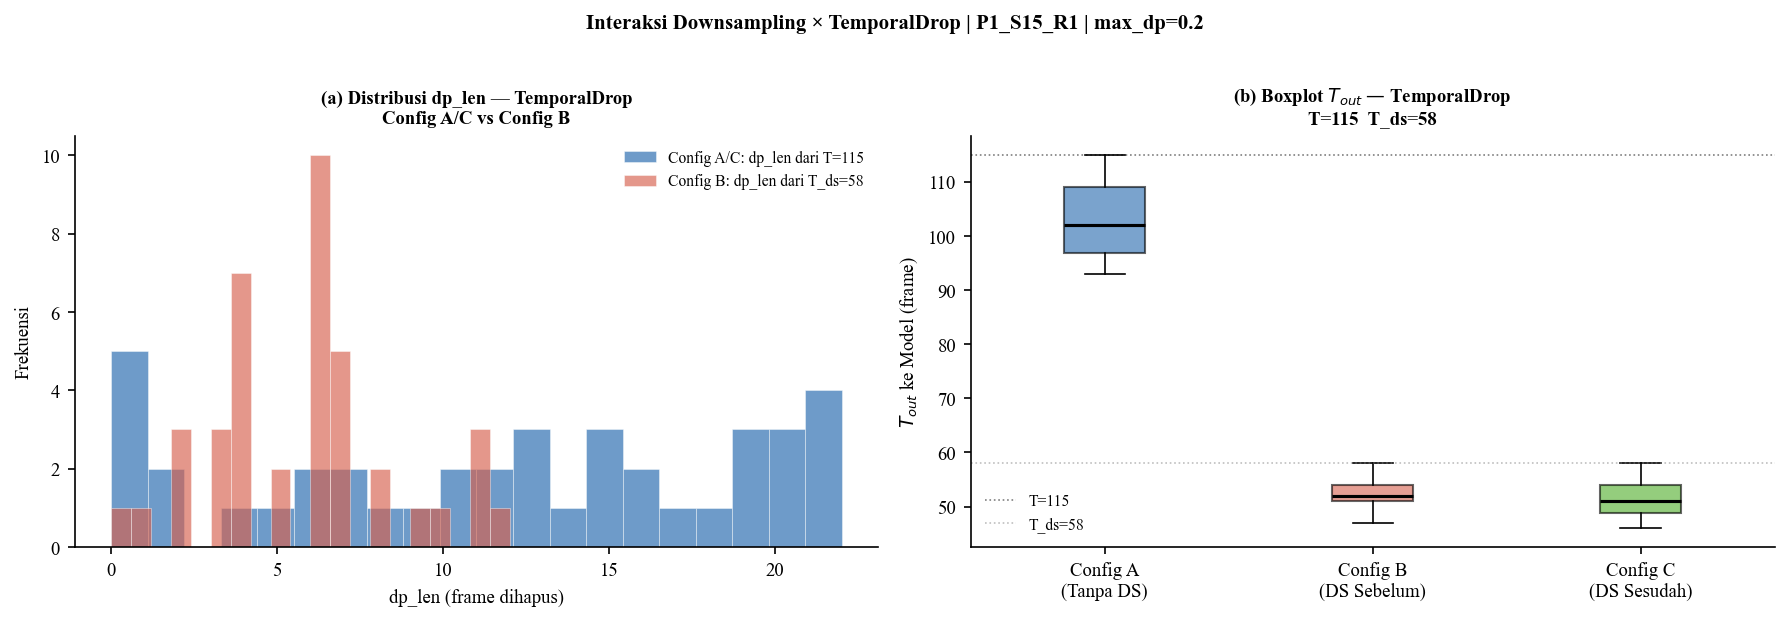

[SAVED] ds_x_temporal_drop.png


In [19]:
np.random.seed(42); random.seed(42)

# ── Tabel deterministik: 5 epoch, bandingkan dp_len dan T_out ────────────────
print('SIM-3a: Efek Posisi DS pada TemporalDrop (5 epoch)')
print(f'T={T}, T_ds={T_ds}, max_dp=0.2')
print(f'dp_len maks Config A/C: int({T}×0.2) = {int(T*0.2)}')
print(f'dp_len maks Config B  : int({T_ds}×0.2) = {int(T_ds*0.2)}')
print('=' * 105)
header = (
    f"{'Ep':<5}"
    f"{'--- Config A/C (T_in=' + str(T) + ') ---':^38}"
    f"{'--- Config B (T_in=' + str(T_ds) + ') ---':^38}"
    f"{'Δ dp_len'}"
)
subheader = (
    f"{'':5}"
    f"{'dp_len':>10}{'start':>10}{'end':>10}{'T_out':>10}"
    f"{'dp_len':>10}{'start':>10}{'end':>10}{'T_out':>10}"
    f"{'':5}{'(A-B)'}"
)
print(subheader)
print('-' * 105)

np.random.seed(7); random.seed(7)
for ep in range(1, 6):
    # Config A/C: T_in = T
    r_ac    = np.random.random()
    dp_ac   = int(T * 0.2 * r_ac)
    st_ac   = np.random.randint(0, T - dp_ac + 1)
    en_ac   = st_ac + dp_ac
    tout_ac = T - dp_ac

    # Config B: T_in = T_ds
    r_b     = np.random.random()
    dp_b    = int(T_ds * 0.2 * r_b)
    st_b    = np.random.randint(0, T_ds - dp_b + 1)
    en_b    = st_b + dp_b
    tout_b  = T_ds - dp_b

    print(
        f"{ep:<5}"
        f"{dp_ac:>10}{st_ac:>10}{en_ac:>10}{tout_ac:>10}"
        f"{dp_b:>10}{st_b:>10}{en_b:>10}{tout_b:>10}"
        f"{'':5}{dp_ac - dp_b:+d}"
    )
print('=' * 105)

# ── Monte Carlo ───────────────────────────────────────────────────────────────
np.random.seed(0); random.seed(0)
tdrop_A, tdrop_B, tdrop_C, dp_A, dp_B = [], [], [], [], []

for _ in range(N_SIM):
    s = skeleton.copy()
    out_a = td(s.copy())
    dp_A.append(T - len(out_a))
    tdrop_A.append(len(out_a))

    s_ds  = ds(s.copy())
    out_b = td(s_ds)
    dp_B.append(T_ds - len(out_b))
    tdrop_B.append(len(out_b))

    out_c = ds(td(s.copy()))
    tdrop_C.append(len(out_c))

tdrop_A = np.array(tdrop_A); tdrop_B = np.array(tdrop_B); tdrop_C = np.array(tdrop_C)
dp_A    = np.array(dp_A);    dp_B    = np.array(dp_B)

print()
print('SIM-3b: Distribusi T_out ke Model — TemporalDrop (N=2000)')
print(f'{"Konfigurasi":<35} {"Min":>6} {"Mean":>8} {"Max":>6} {"Std":>8}')
print('-' * 65)
for label, arr in [(LABEL_A, tdrop_A), (LABEL_B, tdrop_B), (LABEL_C, tdrop_C)]:
    print(f'{label:<35} {arr.min():>6} {arr.mean():>8.1f} {arr.max():>6} {arr.std():>8.1f}')
print()
print(f'dp_len aktual Config A/C — mean: {dp_A.mean():.1f}  max: {dp_A.max()}')
print(f'dp_len aktual Config B   — mean: {dp_B.mean():.1f}  max: {dp_B.max()}')

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(dp_A, bins=20, color=COLOR_A, alpha=0.65, edgecolor='white', lw=0.3,
        label=f'Config A/C: dp_len dari T={T}')
ax.hist(dp_B, bins=20, color=COLOR_B, alpha=0.65, edgecolor='white', lw=0.3,
        label=f'Config B: dp_len dari T_ds={T_ds}')
ax.set_xlabel('dp_len (frame dihapus)', fontsize=9)
ax.set_ylabel('Frekuensi', fontsize=9)
ax.set_title('(a) Distribusi dp_len — TemporalDrop\nConfig A/C vs Config B', fontsize=9)
ax.legend(fontsize=7.5, frameon=False)
for s in ['top','right']: ax.spines[s].set_visible(False)

ax2 = axes[1]
bp = ax2.boxplot(
    [tdrop_A, tdrop_B, tdrop_C],
    labels=['Config A\n(Tanpa DS)', 'Config B\n(DS Sebelum)', 'Config C\n(DS Sesudah)'],
    patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgecolor='none')
)
for patch, c in zip(bp['boxes'], [COLOR_A, COLOR_B, COLOR_C]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax2.axhline(T,    color='black', lw=0.8, ls=':', alpha=0.5, label=f'T={T}')
ax2.axhline(T_ds, color='gray',  lw=0.8, ls=':', alpha=0.5, label=f'T_ds={T_ds}')
ax2.set_ylabel('$T_{out}$ ke Model (frame)', fontsize=9)
ax2.set_title(
    f'(b) Boxplot $T_{{out}}$ — TemporalDrop\nT={T}  T_ds={T_ds}',
    fontsize=9
)
ax2.legend(fontsize=7.5, frameon=False)
for s in ['top','right']: ax2.spines[s].set_visible(False)

fig.suptitle(
    f'Interaksi Downsampling × TemporalDrop | {SELECTED_ID} | max_dp=0.2',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ds_x_temporal_drop.png'), dpi=600, bbox_inches='tight')
plt.show()
print('[SAVED] ds_x_temporal_drop.png')

## Cell 6 — Sim-4: Interaksi DS × Spatial Jitter dan Spatial Scale

Augmentasi spasial (Jitter, Scale) tidak mengubah panjang sekuens, tetapi posisi DS memengaruhi:
- **Jumlah frame** yang mendapat perturbasi
- **Pada Config C**: frame yang sudah di-perturb bisa terbuang saat DS — efektivitas augmentasi berkurang

In [20]:
np.random.seed(0); random.seed(0)

# Untuk Jitter dan Scale, T_out ke model = T atau T_ds tergantung konfigurasi
# Yang berubah adalah BERAPA frame yang terkena augmentasi

print('SIM-4: Interaksi DS × Augmentasi Spasial (Jitter & Scale)')
print('=' * 90)
print(f'{"Konfigurasi":<35} {"T aug":<12} {"Frame di-aug":<16} {"T ke model":<14} {"Keterangan"}')
print('-' * 90)

rows = [
    ('Config A (Tanpa DS)',    T,    T,    T,    'Semua T frame di-augmentasi'),
    ('Config B (DS Sebelum)',  T_ds, T_ds, T_ds, 'Hanya T_ds frame yang di-augmentasi'),
    ('Config C (DS Sesudah)',  T,    T,    T_ds, 'T frame di-aug, lalu DS membuang ~T/2 frame'),
]
for label, t_aug, n_aug, t_model, note in rows:
    print(f'{label:<35} {t_aug:<12} {n_aug:<16} {t_model:<14} {note}')
print('=' * 90)
print()
print('Catatan Config C (DS Sesudah):')
print(f'  Jitter/Scale diterapkan pada {T} frame penuh.')
print(f'  DS kemudian memilih ≈{T_ds} frame (setiap frame ke-2).')
print(f'  Frame yang di-augmentasi namun tidak terpilih DS = tidak masuk ke model.')
print(f'  Secara efektif, hanya ≈{T_ds} dari {T} frame ter-augmentasi yang dilihat model.')
print()

# ── Verifikasi empiris: distribusi noise Jitter yang masuk ke model ───────────
# Simulasi: hitung std noise per frame yang TERPILIH oleh DS
np.random.seed(42)
noise_std_A, noise_std_B, noise_std_C = [], [], []
for _ in range(500):
    s = skeleton.copy().astype(float)

    # Config A: jitter semua, model terima semua
    out_a = jitter(s.copy())
    noise_std_A.append(np.std(out_a - s))

    # Config B: DS dulu, baru jitter
    s_ds  = ds(s.copy())
    out_b = jitter(s_ds)
    # noise relatif terhadap s_ds
    noise_std_B.append(np.std(out_b - s_ds))

    # Config C: jitter dulu, DS kemudian
    s_jit = jitter(s.copy())
    out_c = ds(s_jit)
    s_ds2 = ds(s.copy())
    # noise hanya dari frame yang terpilih DS
    n = min(len(out_c), len(s_ds2))
    noise_std_C.append(np.std(out_c[:n] - s_ds2[:n]))

noise_std_A = np.array(noise_std_A)
noise_std_B = np.array(noise_std_B)
noise_std_C = np.array(noise_std_C)

print('Std noise Jitter yang masuk ke model (500 simulasi):')
print(f'  Config A: {noise_std_A.mean():.5f} ± {noise_std_A.std():.5f}')
print(f'  Config B: {noise_std_B.mean():.5f} ± {noise_std_B.std():.5f}')
print(f'  Config C: {noise_std_C.mean():.5f} ± {noise_std_C.std():.5f}')
print()
print('→ Std noise identik antar konfigurasi: Jitter tidak terpengaruh posisi DS')
print('  (noise per-keypoint per-frame tidak bergantung pada panjang sekuens)')
print()

# ── Scale: verifikasi distribusi faktor skala yang diterima model ─────────────
print('Scale — jumlah nilai s_t yang disampling per konfigurasi:')
print(f'  Config A: {T} nilai s_t (satu per frame, frame penuh)')
print(f'  Config B: {T_ds} nilai s_t (hanya untuk T_ds frame)')
print(f'  Config C: {T} nilai s_t disampling, DS pilih ≈{T_ds} → model terima subset s_t')
print()
print('→ Distribusi s_t U(0.8, 1.2) tidak berubah, tetapi')
print(f'  Config B menghasilkan variasi temporal scaling yang lebih sempit')
print(f'  karena hanya {T_ds} faktor independen (bukan {T})')

SIM-4: Interaksi DS × Augmentasi Spasial (Jitter & Scale)
Konfigurasi                         T aug        Frame di-aug     T ke model     Keterangan
------------------------------------------------------------------------------------------
Config A (Tanpa DS)                 115          115              115            Semua T frame di-augmentasi
Config B (DS Sebelum)               58           58               58             Hanya T_ds frame yang di-augmentasi
Config C (DS Sesudah)               115          115              58             T frame di-aug, lalu DS membuang ~T/2 frame

Catatan Config C (DS Sesudah):
  Jitter/Scale diterapkan pada 115 frame penuh.
  DS kemudian memilih ≈58 frame (setiap frame ke-2).
  Frame yang di-augmentasi namun tidak terpilih DS = tidak masuk ke model.
  Secara efektif, hanya ≈58 dari 115 frame ter-augmentasi yang dilihat model.

Std noise Jitter yang masuk ke model (500 simulasi):
  Config A: 0.00600 ± 0.00003
  Config B: 0.00600 ± 0.00004
  Config

## Cell 7 — Viz-1: Ringkasan Distribusi $T_{out}$ Semua Konfigurasi × Augmentasi

Visualisasi komprehensif yang merangkum efek posisi downsampling pada semua metode augmentasi.

RINGKASAN T_out ke Model: Semua Konfigurasi × Augmentasi (N=2000)
Augmentasi         Config        Min     Mean    Max      Std    Range
----------------------------------------------------------------------------------------------------
Jitter             A            115    115.0    115      0.0        0
Jitter             B             57     57.5     58      0.5        1
Jitter             C             57     57.2     58      0.4        1
----------------------------------------------------------------------------------------------------
Scale              A            115    115.0    115      0.0        0
Scale              B             57     57.4     58      0.5        1
Scale              C             57     57.5     58      0.5        1
----------------------------------------------------------------------------------------------------
TemporalDrop       A             94    105.0    115      6.8       21
TemporalDrop       B             47     52.1     58      3.3       11


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\2892086882.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\2892086882.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\2892086882.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_12608\2892086882.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped 

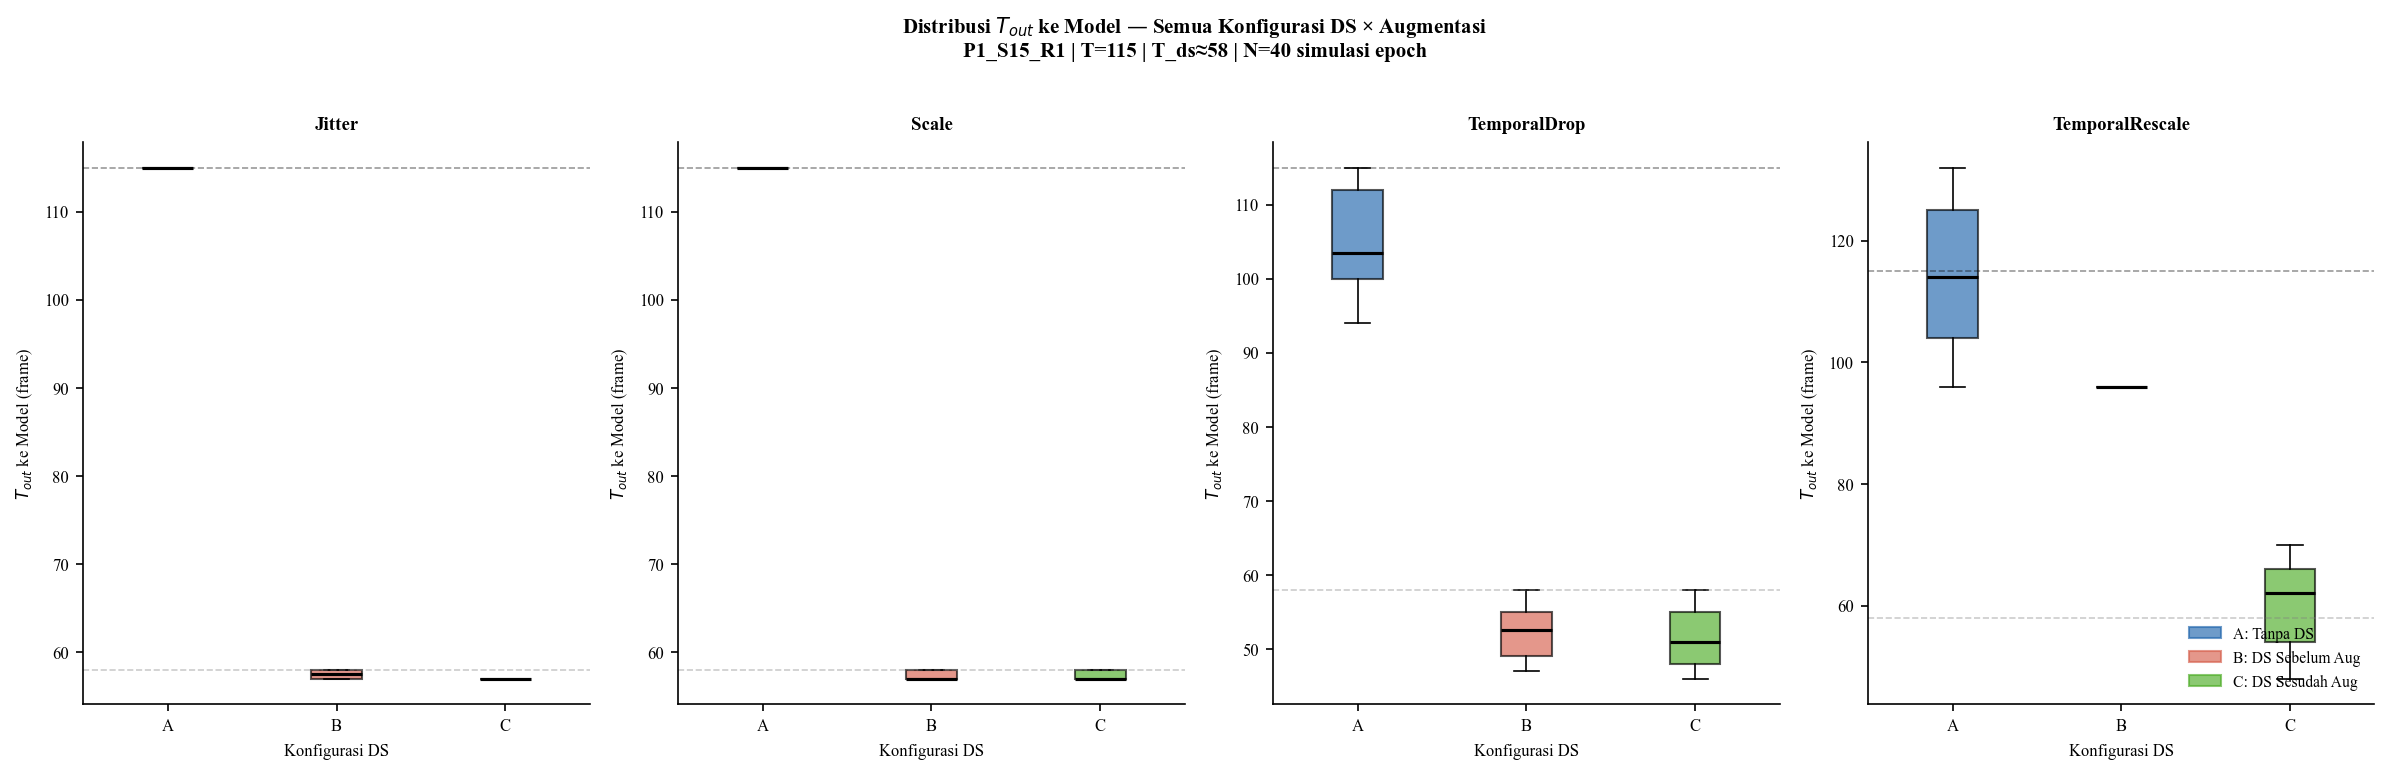

[SAVED] ds_summary_all_aug.png


In [21]:
np.random.seed(0); random.seed(0)

AUG_NAMES = ['Jitter', 'Scale', 'TemporalDrop', 'TemporalRescale']
aug_map   = {'Jitter': jitter, 'Scale': scale, 'TemporalDrop': td, 'TemporalRescale': tr}

# Kumpulkan T_out untuk semua kombinasi (3 config × 4 aug)
results = {aug: {'A': [], 'B': [], 'C': []} for aug in AUG_NAMES}

for _ in range(N_SIM):
    s = skeleton.copy()
    for aug_name, aug_fn in aug_map.items():
        kw = {'sentence_id': sentence_id} if aug_name == 'TemporalRescale' else {}

        # Config A
        results[aug_name]['A'].append(len(aug_fn(s.copy(), **kw)))
        # Config B: DS → aug
        results[aug_name]['B'].append(len(aug_fn(ds(s.copy()), **kw)))
        # Config C: aug → DS
        results[aug_name]['C'].append(len(ds(aug_fn(s.copy(), **kw))))

for aug_name in AUG_NAMES:
    for cfg in 'ABC':
        results[aug_name][cfg] = np.array(results[aug_name][cfg])

# ── Tabel ringkasan ───────────────────────────────────────────────────────────
print('RINGKASAN T_out ke Model: Semua Konfigurasi × Augmentasi (N=2000)')
print('=' * 100)
print(f'{"Augmentasi":<18} {"Config":<10} {"Min":>6} {"Mean":>8} {"Max":>6} {"Std":>8} {"Range":>8}')
print('-' * 100)
for aug_name in AUG_NAMES:
    for cfg, label in [('A', LABEL_A), ('B', LABEL_B), ('C', LABEL_C)]:
        arr = results[aug_name][cfg]
        print(
            f'{aug_name:<18} {cfg:<10}'
            f'{arr.min():>6} {arr.mean():>8.1f} {arr.max():>6} '
            f'{arr.std():>8.1f} {arr.max()-arr.min():>8}'
        )
    print('-' * 100)

# ── Visualisasi grid 4×1 boxplot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, aug_name in zip(axes, AUG_NAMES):
    data_bp = [results[aug_name]['A'], results[aug_name]['B'], results[aug_name]['C']]
    bp = ax.boxplot(
        data_bp,
        labels=['A', 'B', 'C'],
        patch_artist=True,
        medianprops=dict(color='black', lw=1.5),
        whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
        flierprops=dict(marker='o', markersize=2, alpha=0.25, markeredgecolor='none')
    )
    for patch, c in zip(bp['boxes'], [COLOR_A, COLOR_B, COLOR_C]):
        patch.set_facecolor(c); patch.set_alpha(0.65)

    # Garis referensi
    ax.axhline(T,    color='black', lw=0.8, ls='--', alpha=0.4, label=f'T={T}')
    ax.axhline(T_ds, color='gray',  lw=0.8, ls='--', alpha=0.4, label=f'T_ds={T_ds}')

    ax.set_title(aug_name, fontsize=9)
    ax.set_xlabel('Konfigurasi DS', fontsize=8)
    ax.set_ylabel('$T_{out}$ ke Model (frame)', fontsize=8)
    ax.tick_params(labelsize=8)
    for s in ['top','right']: ax.spines[s].set_visible(False)

axes[-1].legend(
    handles=[
        mpatches.Patch(color=COLOR_A, alpha=0.65, label='A: Tanpa DS'),
        mpatches.Patch(color=COLOR_B, alpha=0.65, label='B: DS Sebelum Aug'),
        mpatches.Patch(color=COLOR_C, alpha=0.65, label='C: DS Sesudah Aug'),
    ],
    fontsize=7.5, frameon=False, loc='lower right'
)

fig.suptitle(
    f'Distribusi $T_{{out}}$ ke Model — Semua Konfigurasi DS × Augmentasi\n'
    f'{SELECTED_ID} | T={T} | T_ds≈{T_ds} | N={N_SIM} simulasi epoch',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ds_summary_all_aug.png'), dpi=600, bbox_inches='tight')
plt.show()
print('[SAVED] ds_summary_all_aug.png')

## Cell 8 — Viz-2: Timeline 3 Konfigurasi pada 1 Video (5 Epoch)

Visualisasi kualitatif: untuk augmentasi TemporalDrop dan TemporalRescale (yang paling dipengaruhi posisi DS), tampilkan perbedaan frame yang diterima model per konfigurasi.

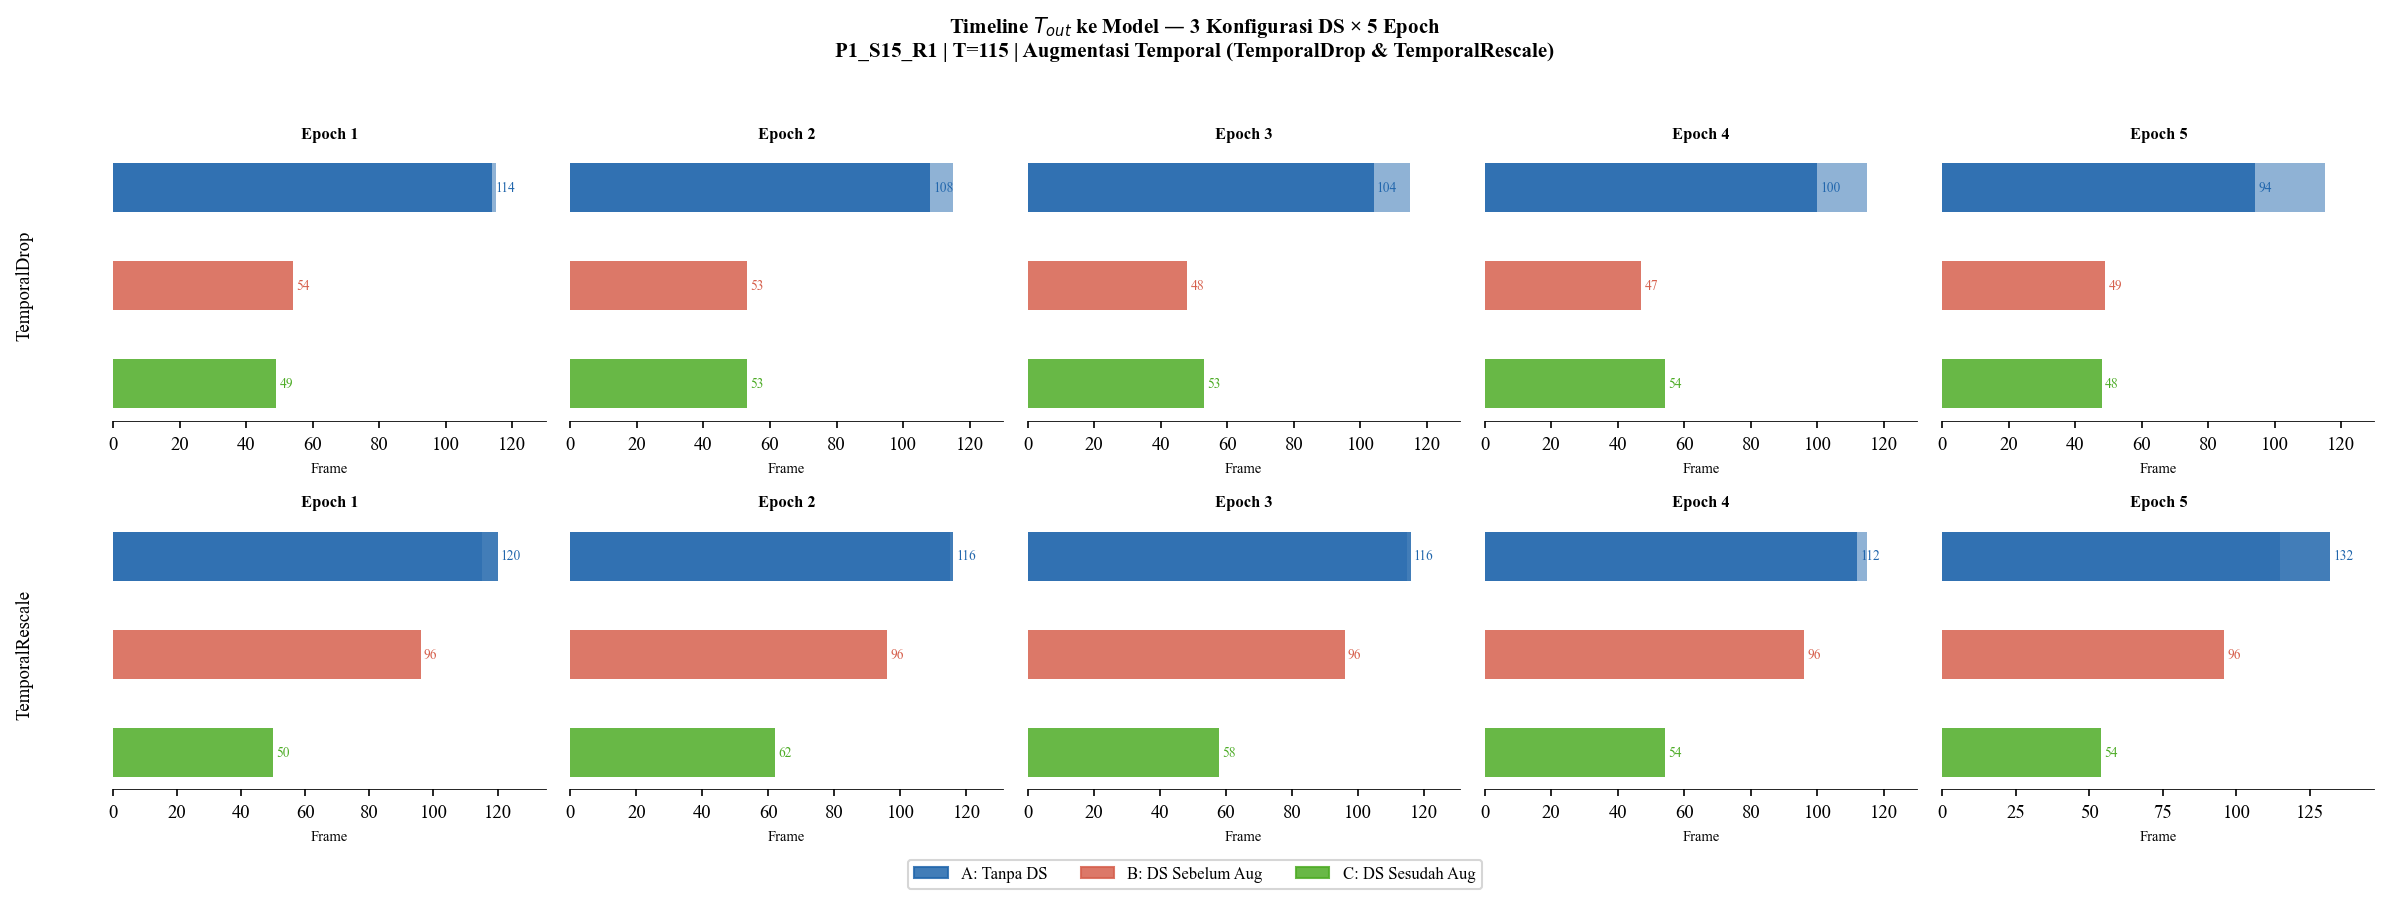

[SAVED] ds_timeline_5epoch.png


In [22]:
np.random.seed(7); random.seed(7)

VIZ_AUGS = ['TemporalDrop', 'TemporalRescale']
viz_aug_map = {'TemporalDrop': td, 'TemporalRescale': tr}

fig, axes = plt.subplots(2, N_EPOCHS, figsize=(16, 5.5), sharey='row')

for row, aug_name in enumerate(VIZ_AUGS):
    aug_fn = viz_aug_map[aug_name]
    kw     = {'sentence_id': sentence_id} if aug_name == 'TemporalRescale' else {}

    for ep in range(N_EPOCHS):
        ax = axes[row, ep]
        s  = skeleton.copy()

        # Config A
        out_a = aug_fn(s.copy(), **kw)
        T_a   = len(out_a)

        # Config B: DS → aug
        out_b = aug_fn(ds(s.copy()), **kw)
        T_b   = len(out_b)

        # Config C: aug → DS
        out_c = ds(aug_fn(s.copy(), **kw))
        T_c   = len(out_c)

        # Bar horizontal
        ax.barh(2, T,   left=0, height=0.5, color=COLOR_A, alpha=0.5)  # baseline ref
        ax.barh(2, T_a, left=0, height=0.5, color=COLOR_A, alpha=0.85)
        ax.barh(1, T_b, left=0, height=0.5, color=COLOR_B, alpha=0.85)
        ax.barh(0, T_c, left=0, height=0.5, color=COLOR_C, alpha=0.85)

        # Anotasi panjang
        ax.text(T_a + 1, 2, str(T_a), va='center', fontsize=6.5, color=COLOR_A)
        ax.text(T_b + 1, 1, str(T_b), va='center', fontsize=6.5, color=COLOR_B)
        ax.text(T_c + 1, 0, str(T_c), va='center', fontsize=6.5, color=COLOR_C)

        ax.set_xlim(0, max(T, T_a, T_b, T_c) + 15)
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['C', 'B', 'A'] if ep == 0 else [], fontsize=8)
        ax.set_title(f'Epoch {ep+1}', fontsize=8)
        ax.set_xlabel('Frame', fontsize=7)
        for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
        ax.spines['bottom'].set_linewidth(0.4)
        ax.tick_params(axis='y', length=0)

    # Label baris
    axes[row, 0].set_ylabel(aug_name, fontsize=9, labelpad=35)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_A, alpha=0.85, label='A: Tanpa DS'),
        mpatches.Patch(color=COLOR_B, alpha=0.85, label='B: DS Sebelum Aug'),
        mpatches.Patch(color=COLOR_C, alpha=0.85, label='C: DS Sesudah Aug'),
    ],
    loc='lower center', ncol=3, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.04)
)
fig.suptitle(
    f'Timeline $T_{{out}}$ ke Model — 3 Konfigurasi DS × 5 Epoch\n'
    f'{SELECTED_ID} | T={T} | Augmentasi Temporal (TemporalDrop & TemporalRescale)',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ds_timeline_5epoch.png'), dpi=600, bbox_inches='tight')
plt.show()
print('[SAVED] ds_timeline_5epoch.png')